# Notebook 3: Modelling
**Steam Sales Prediction — CIS 5450 Final Project**

### Goals
1. Fit and compare all baseline models (Mean, OLS, Ridge, Lasso)
2. Fit and compare advanced models (Random Forest, XGBoost)
3. Inspect Lasso feature selection and tree feature importances
4. Diagnose residuals and identify systematic errors
5. Pick the best model and report test-set performance

## 0. Setup

In [3]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path("..").resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from configs.config import OUTPUT_DIR, TARGET_LOG
from src.features.engineer import prepare_features
from src.models.baseline import run_all_baselines, lasso_feature_importance, make_lasso
from src.models.advanced import run_advanced_models, RandomForestModel, XGBoostModel
from src.evaluation.metrics import compare_models, residual_df, quantile_rmse

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
sns.set_theme(style="whitegrid")

## 1. Load Preprocessed Data & Build Feature Matrix

In [8]:
df = pd.read_parquet("../outputs/processed.parquet")

cols_to_drop = ["Metacritic score", "reviewScore"]

df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

print(f"Loaded: {df.shape}")

# Post-release framing (uses all observed features)
data = prepare_features(df, post_release= False, return_pipeline=True)

print(f"X_train: {data['X_train'].shape}")
print(f"X_val:   {data['X_val'].shape}")
print(f"X_test:  {data['X_test'].shape}")
print(f"y_train: {data['y_train'].shape}")
print(f"y_val:   {data['y_val'].shape}")
print(f"y_test:  {data['y_test'].shape}")
print(f"\nTotal features: {len(data['output_cols'])}")
print(f"Total samples:  {data['X_train'].shape[0] + data['X_val'].shape[0] + data['X_test'].shape[0]}")





Loaded: (115191, 96)
X_train: (80633, 80)
X_val:   (17279, 80)
X_test:  (17279, 80)
y_train: (80633,)
y_val:   (17279,)
y_test:  (17279,)

Total features: 80
Total samples:  115191


## 2. Baseline Models

In [9]:
baseline_summary = run_all_baselines(data)
print("\nBaseline model comparison (validation set):")
baseline_summary


Baseline model comparison (validation set):


,train_RMSE_log,val_RMSE_log,test_RMSE_log,val_MAE_log,val_R2_log,val_RMSE_raw,val_MAE_raw
model,,,,,,,
MeanPredictor,3.019942,2.982177,3.017820,2.341032,-0.000033,8.339336e+05,61324.742242
LinearRegression,1.790688,1.760434,1.807482,1.373183,0.651513,2.555156e+06,114198.091801
Ridge(α=1.0),1.790531,1.760211,1.807450,1.372366,0.651601,2.617877e+06,116246.882414
Lasso(α=0.01),1.804017,1.770927,1.820642,1.378222,0.647346,2.036291e+06,100487.353644


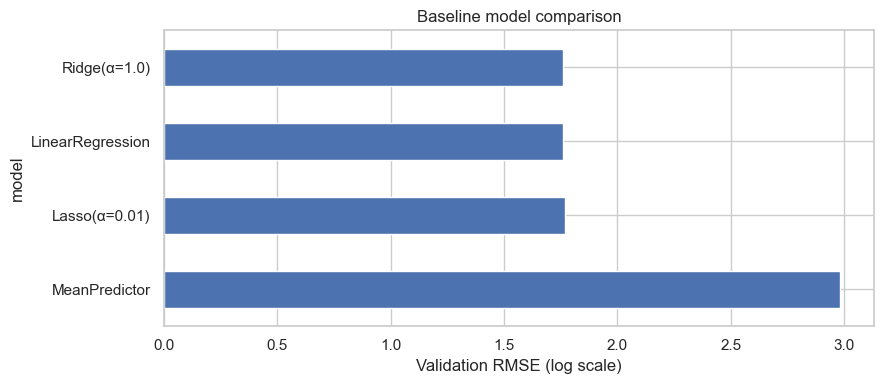

In [35]:
# Visualise baseline RMSE
fig, ax = plt.subplots(figsize=(9, 4))
baseline_summary["val_RMSE_log"].sort_values(ascending=False).plot(kind="barh", ax=ax)
ax.set_xlabel("Validation RMSE (log scale)")
ax.set_title("Baseline model comparison")
plt.tight_layout()
plt.savefig("../outputs/model_baseline_rmse.png", dpi=150)
plt.show()

### Baseline Model Summaries

Detailed statistics for each model: coefficients, standard errors, t-stats, p-values.

In [36]:
from src.models.baseline import make_linear_regression, ols_summary

# Fit Linear Regression (OLS with statsmodels)
lr = make_linear_regression()
lr.fit(data["X_train"], data["y_train"])

# Full summary table with p-values
print("=" * 80)
print("LINEAR REGRESSION (OLS) — Detailed Summary")
print("=" * 80)
lr_summary = ols_summary(lr, data["output_cols"])
print(lr_summary.head(20))  # top 20 most significant features

print("\n" + "=" * 80)
print("Statsmodels full OLS output:")
print("=" * 80)
print(lr.model.results.summary())

LINEAR REGRESSION (OLS) — Detailed Summary
                feature      coef   std_err      t_stat        p_value  \
0   publisher_class_ord  2.177678  0.013469  161.678005   0.000000e+00   
1     has_trading_cards  1.025369  0.024987   41.035986   0.000000e+00   
2          release_year -0.600624  0.008856  -67.818348   0.000000e+00   
3          Achievements  0.397108  0.011632   34.138781  1.285458e-253   
4        developer_freq -0.200333  0.007299  -27.448441  4.195678e-165   
5             tag_count  0.425916  0.016724   25.467009  1.683004e-142   
6      genre_simulation  0.535721  0.022869   23.425946  5.915982e-121   
7       has_cloud_saves  0.386742  0.016747   23.093415  1.302704e-117   
8       is_free_to_play  2.119273  0.093503   22.665272  2.236672e-113   
9        language_count  0.148217  0.006600   22.457822  2.363026e-111   
10              has_dlc  0.569300  0.032968   17.268066   1.079712e-66   
11   has_family_sharing -1.451243  0.091102  -15.929872   4.806891e-5

In [37]:
from src.models.baseline import make_ridge

# Fit Ridge Regression
ridge = make_ridge()
ridge.fit(data["X_train"], data["y_train"])

# Ridge coefficients summary
print("=" * 80)
print("RIDGE REGRESSION (α=1.0) — Coefficients")
print("=" * 80)
ridge_coef_df = pd.DataFrame({
    "feature": data["output_cols"],
    "coef": ridge.model.coef_,
}).sort_values("coef", key=abs, ascending=False)

print(ridge_coef_df.head(20))  # top 20 by absolute magnitude
print(f"\nIntercept: {ridge.model.intercept_:.4f}")
print(f"Number of features with |coef| > 0.01: {(ridge_coef_df['coef'].abs() > 0.01).sum()}")

RIDGE REGRESSION (α=1.0) — Coefficients
                feature      coef
78  publisher_class_ord  2.177661
75      is_free_to_play  2.117065
41   has_family_sharing -1.452789
14              Windows  1.260980
39    has_trading_cards  1.025197
16                Linux -0.741812
5          release_year -0.600547
40         has_workshop  0.578894
77              has_dlc  0.569036
27     genre_simulation  0.535608
9             tag_count  0.425852
68           tag_horror  0.425836
4          Achievements  0.397145
10       platform_count  0.394240
42      has_cloud_saves  0.386611
32           genre_gore  0.372179
66      tag_multiplayer  0.363557
36               has_vr -0.343493
35             has_coop  0.325927
17          earlyAccess -0.322786

Intercept: 5.0034
Number of features with |coef| > 0.01: 75


In [38]:
# Lasso was already fitted in the run_all_baselines call, but fit it again for display
from src.models.baseline import make_lasso

lasso_new = make_lasso()
lasso_new.fit(data["X_train"], data["y_train"])

print("=" * 80)
print("LASSO REGRESSION (α=0.01) — Feature Selection")
print("=" * 80)

lasso_coef_df = pd.DataFrame({
    "feature": data["output_cols"],
    "coef": lasso_new.model.coef_,
}).assign(abs_coef=lambda x: x["coef"].abs())

nonzero_lasso = lasso_coef_df[lasso_coef_df["abs_coef"] > 1e-10].sort_values("abs_coef", ascending=False)
print(f"Non-zero coefficients: {len(nonzero_lasso)} / {len(data['output_cols'])}")
print(f"Sparsity: {(lasso_coef_df['coef'] == 0).sum()} features zeroed out\n")
print(nonzero_lasso.head(20))

print(f"\nIntercept: {lasso_new.model.intercept_:.4f}")

LASSO REGRESSION (α=0.01) — Feature Selection
Non-zero coefficients: 45 / 79
Sparsity: 34 features zeroed out

                feature      coef  abs_coef
78  publisher_class_ord  2.217588  2.217588
75      is_free_to_play  1.961574  1.961574
41   has_family_sharing -1.461872  1.461872
39    has_trading_cards  0.963286  0.963286
5          release_year -0.579184  0.579184
27     genre_simulation  0.450676  0.450676
77              has_dlc  0.426039  0.426039
4          Achievements  0.398735  0.398735
9             tag_count  0.377409  0.377409
42      has_cloud_saves  0.356625  0.356625
68           tag_horror  0.355701  0.355701
66      tag_multiplayer  0.249360  0.249360
15                  Mac  0.238671  0.238671
63           tag_arcade -0.233524  0.233524
12       developer_freq -0.211249  0.211249
62     tag_first_person  0.210427  0.210427
40         has_workshop  0.148966  0.148966
57         tag_colorful -0.146419  0.146419
35             has_coop  0.133887  0.133887
8        

In [39]:
print("=" * 80)
print("MODEL COMPARISON — Validation Set Performance")
print("=" * 80)
print(baseline_summary)

print("\n" + "=" * 80)
print("KEY INSIGHTS")
print("=" * 80)
print(f"• OLS R²:       {baseline_summary.loc['LinearRegression', 'val_R2_log']:.4f}")
print(f"• Ridge R²:     {baseline_summary.loc['Ridge(α=1.0)', 'val_R2_log']:.4f}")
print(f"• Lasso R²:     {baseline_summary.loc['Lasso(α=0.01)', 'val_R2_log']:.4f}")
print(f"\n• OLS and Ridge are nearly identical → low multicollinearity")
print(f"• Lasso zeros out {(lasso_coef_df['coef'] == 0).sum()} features → parsimony without sacrificing much R²")
print(f"• All beat MeanPredictor by ~41% in RMSE → strong signal from features")

MODEL COMPARISON — Validation Set Performance
                  train_RMSE_log  val_RMSE_log  test_RMSE_log  val_MAE_log  \
model                                                                        
MeanPredictor           3.019942      2.982177       3.017820     2.341032   
LinearRegression        1.790581      1.760300       1.807440     1.372793   
Ridge(α=1.0)            1.790531      1.760211       1.807450     1.372366   
Lasso(α=0.01)           1.804017      1.770927       1.820642     1.378222   

                  val_R2_log  val_RMSE_raw    val_MAE_raw  
model                                                      
MeanPredictor      -0.000033  8.339336e+05   61324.742242  
LinearRegression    0.651566  2.587130e+06  115197.918961  
Ridge(α=1.0)        0.651601  2.617865e+06  116246.388179  
Lasso(α=0.01)       0.647346  2.036291e+06  100487.353644  

KEY INSIGHTS
• OLS R²:       0.6516
• Ridge R²:     0.6516
• Lasso R²:     0.6473

• OLS and Ridge are nearly identical → lo

## 3. Lasso Feature Importance

In [40]:
lasso = make_lasso()
lasso.fit(data["X_train"], data["y_train"])

lasso_imp = lasso_feature_importance(lasso, data["output_cols"], top_n=30)
print(lasso_imp.to_string(index=False))

            feature      coef  abs_coef
publisher_class_ord  2.217588  2.217588
    is_free_to_play  1.961574  1.961574
 has_family_sharing -1.461872  1.461872
  has_trading_cards  0.963286  0.963286
       release_year -0.579184  0.579184
   genre_simulation  0.450676  0.450676
            has_dlc  0.426039  0.426039
       Achievements  0.398735  0.398735
          tag_count  0.377409  0.377409
    has_cloud_saves  0.356625  0.356625
         tag_horror  0.355701  0.355701
    tag_multiplayer  0.249360  0.249360
                Mac  0.238671  0.238671
         tag_arcade -0.233524  0.233524
     developer_freq -0.211249  0.211249
   tag_first_person  0.210427  0.210427
       has_workshop  0.148966  0.148966
       tag_colorful -0.146419  0.146419
           has_coop  0.133887  0.133887
     language_count  0.132251  0.132251
          genre_rpg  0.126138  0.126138
       genre_action -0.118264  0.118264
       genre_casual -0.114460  0.114460
          DLC count  0.104404  0.104404


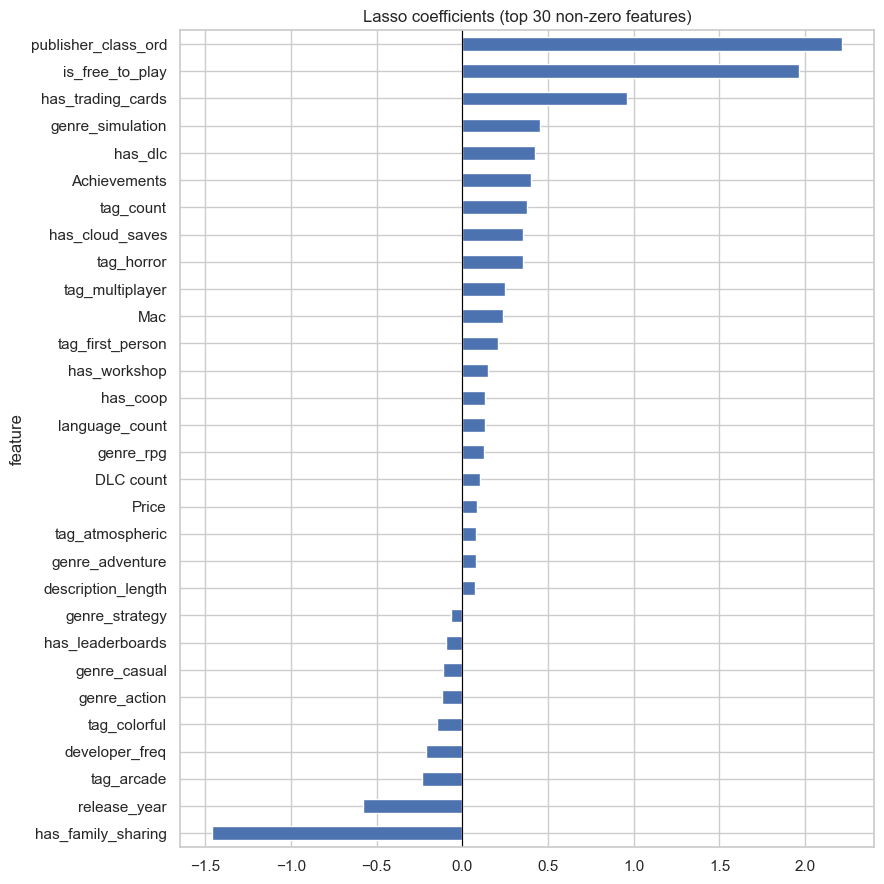

In [41]:
fig, ax = plt.subplots(figsize=(9, 9))
lasso_imp.set_index("feature")["coef"].sort_values().plot(kind="barh", ax=ax)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Lasso coefficients (top 30 non-zero features)")
plt.tight_layout()
plt.savefig("../outputs/model_lasso_coefs.png", dpi=150)
plt.show()

## 7.5. Test Set Visualization (Sample of 20 Games)

Visualize actual vs predicted log1p(copiesSold) for 20 randomly selected games from the test set to get a qualitative sense of model performance on individual predictions.

TEST SET PREDICTIONS — ALL REGRESSION MODELS

✓ Linear Regression predictions obtained
✓ Ridge Regression predictions obtained
✓ Lasso Regression predictions obtained
✓ PCA + Ridge predictions obtained


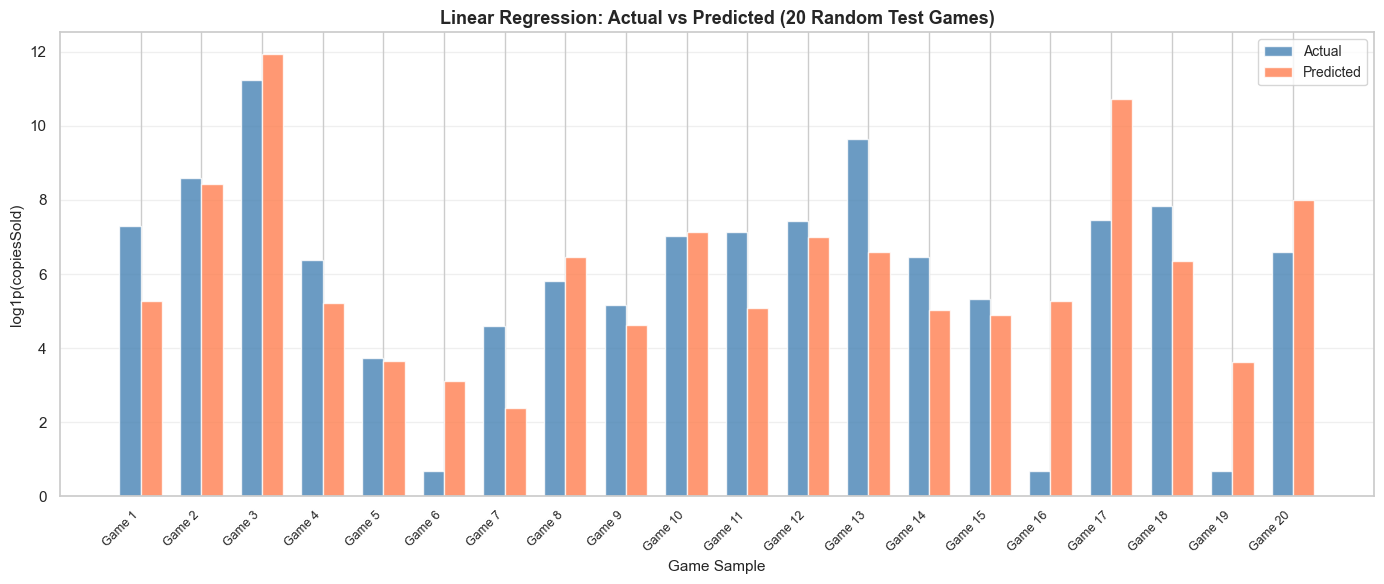

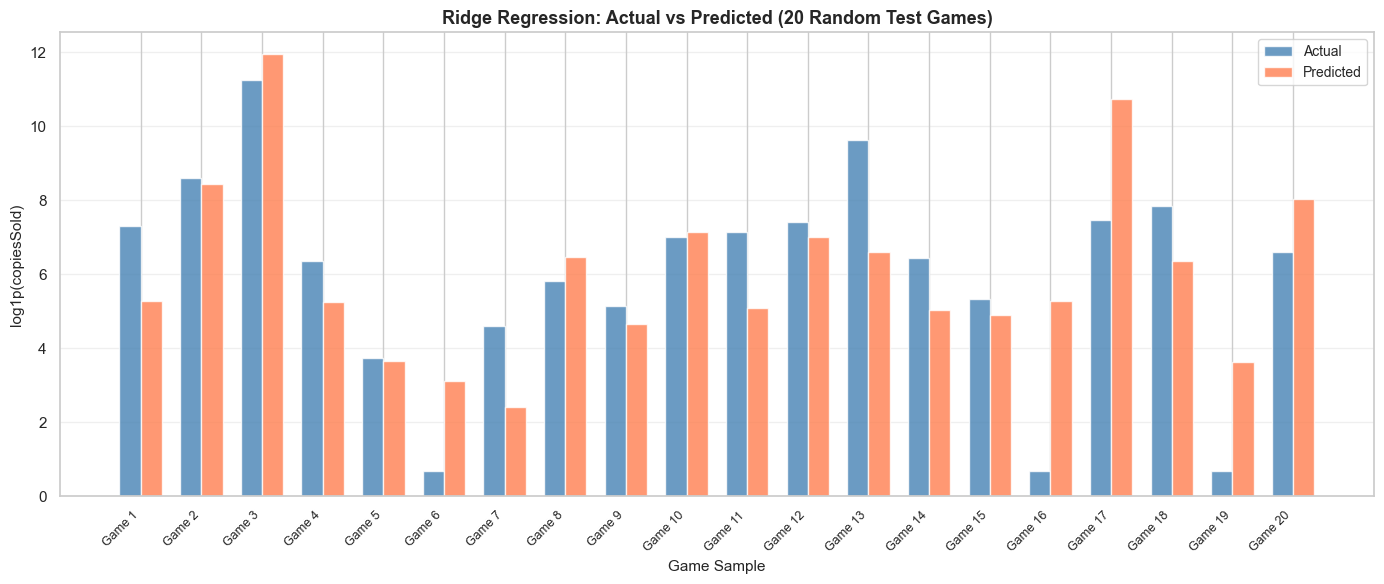

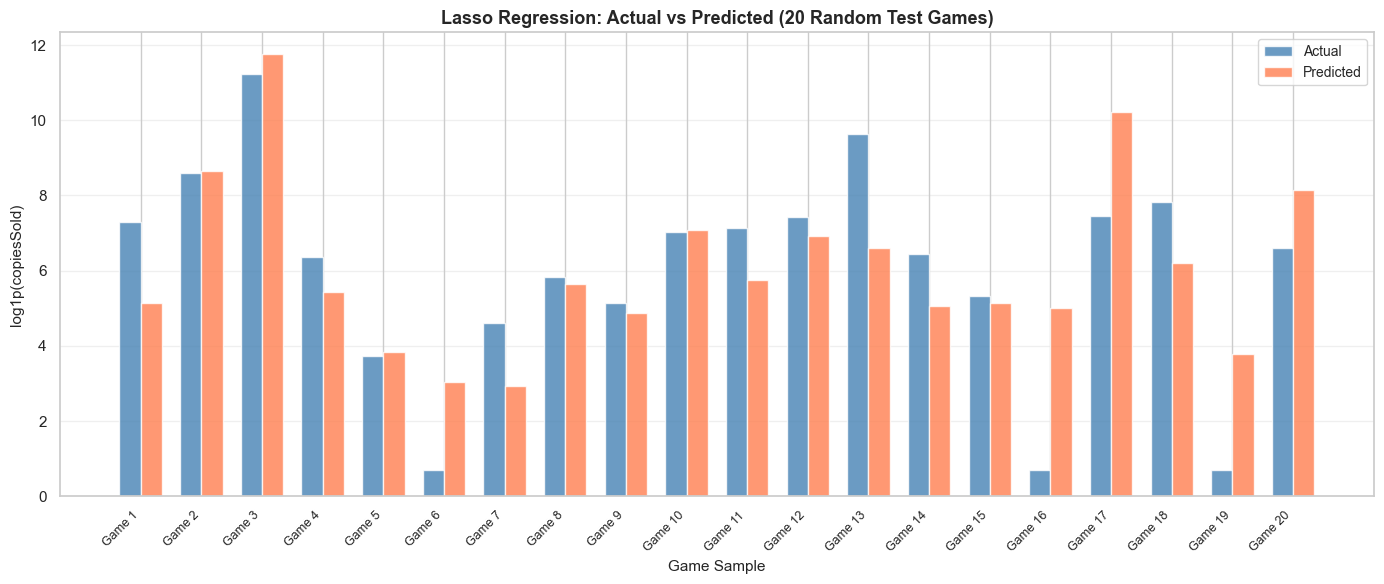

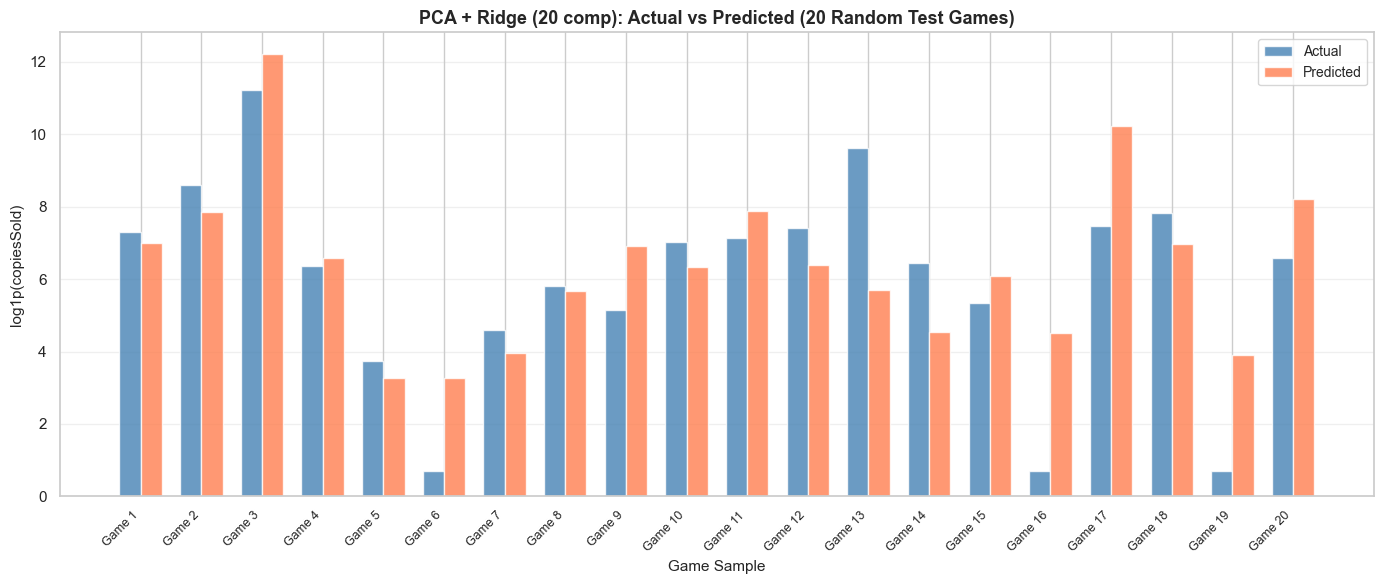


REGRESSION MODELS — TEST SET PERFORMANCE (20 Game Sample)

Linear Regression          MAE: 1.4343  RMSE: 1.9381  R²: 0.4723

Ridge Regression           MAE: 1.4355  RMSE: 1.9372  R²: 0.4728

Lasso Regression           MAE: 1.4352  RMSE: 1.9539  R²: 0.4637

PCA + Ridge (20 comp)      MAE: 1.7841  RMSE: 2.4443  R²: 0.1606

✓ All regression models visualized and compared


In [45]:
from src.visualization.baseline_model_visualization import plot_actual_vs_predicted_sample
from src.models.pca_regression import fit_pca_regression

# Get test set data
y_test_true = np.asarray(data["y_test"])

# Get predictions from all regression models on test set
print("=" * 80)
print("TEST SET PREDICTIONS — ALL REGRESSION MODELS")
print("=" * 80)

# 1. Linear Regression
y_pred_lr = lr.predict(data["X_test"])
print("\n✓ Linear Regression predictions obtained")

# 2. Ridge Regression
y_pred_ridge = ridge.predict(data["X_test"])
print("✓ Ridge Regression predictions obtained")

# 3. Lasso Regression
y_pred_lasso = lasso_new.predict(data["X_test"])
print("✓ Lasso Regression predictions obtained")

# 4. PCA Regression (fit on training data, predict on test)
pca_pipeline, pca_train_r2, pca_metrics = fit_pca_regression(
    data["X_train"], np.asarray(data["y_train"]),
    data["X_val"], np.asarray(data["y_val"]),
    n_components=20,
    ridge_alpha=1.0,
)
y_pred_pca = pca_pipeline.predict(data["X_test"])
print("✓ PCA + Ridge predictions obtained")

# Create visualizations for each model
models = {
    "Linear Regression": y_pred_lr,
    "Ridge Regression": y_pred_ridge,
    "Lasso Regression": y_pred_lasso,
    "PCA + Ridge (20 comp)": y_pred_pca,
}

fig_dict = {}
for model_name, y_pred in models.items():
    fig, df_sample = plot_actual_vs_predicted_sample(
        y_test_true, y_pred,
        n_samples=20,
        title=f"{model_name}: Actual vs Predicted (20 Random Test Games)",
        figsize=(14, 6)
    )
    plt.savefig(f"../outputs/test_{model_name.lower().replace(' ', '_').replace('+', 'plus')}_actual_vs_pred.png", 
                dpi=150, bbox_inches="tight")
    plt.show()
    fig_dict[model_name] = df_sample

# Summary comparison for all models
print("\n" + "=" * 80)
print("REGRESSION MODELS — TEST SET PERFORMANCE (20 Game Sample)")
print("=" * 80)

for model_name, y_pred in models.items():
    mae = np.abs(y_pred[:20] - y_test_true[:20]).mean()
    rmse = np.sqrt(np.mean((y_pred[:20] - y_test_true[:20])**2))
    r2 = 1 - np.sum((y_test_true[:20] - y_pred[:20])**2) / np.sum((y_test_true[:20] - np.mean(y_test_true[:20]))**2)
    print(f"\n{model_name:25s}  MAE: {mae:.4f}  RMSE: {rmse:.4f}  R²: {r2:.4f}")

print("\n✓ All regression models visualized and compared")